In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from utility_functions import *

## Read the Output Files

In [3]:
buildings_unmitigated = pd.read_csv('outputs/building_out.csv')
buildings_mitigated = pd.read_csv('outputs/building_mitigated_out.csv')

edges_unmitigated = pd.read_csv('outputs/edges_out.csv', index_col = 0)
edges_mitigated = pd.read_csv('outputs/edges_mitigated_out.csv', index_col = 0)

nodes_unmitigated = pd.read_csv('outputs/nodes_out.csv', index_col = 0)
nodes_mitigated = pd.read_csv('outputs/nodes_mitigated_out.csv', index_col = 0)


## Compare Building Downtimes

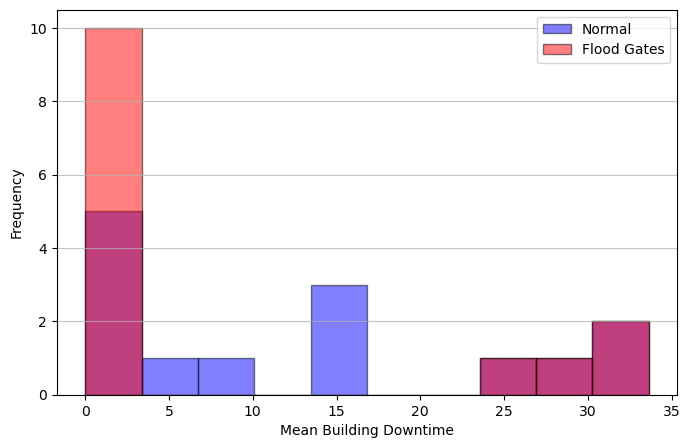

In [5]:
plt.figure(figsize=(8, 5))

plt.hist(buildings_unmitigated['mean_downtime'], bins = 10, color = 'blue', edgecolor = 'black', alpha = 0.5, label = 'Normal')
plt.hist(buildings_mitigated['mean_downtime'], bins = 10, color = 'red', edgecolor = 'black', alpha = 0.5, label = 'Flood Gates')
# Customize the plotplt.set_title('Building Downtime Comparison')
plt.xlabel('Mean Building Downtime')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

plt.legend()
# Show plot
plt.show()

In [6]:
buildings_unmitigated.mean_downtime.mean()

12.859222688499415

In [7]:
buildings_mitigated.mean_downtime.mean()

8.770702483948408

## Compare Power Downtimes

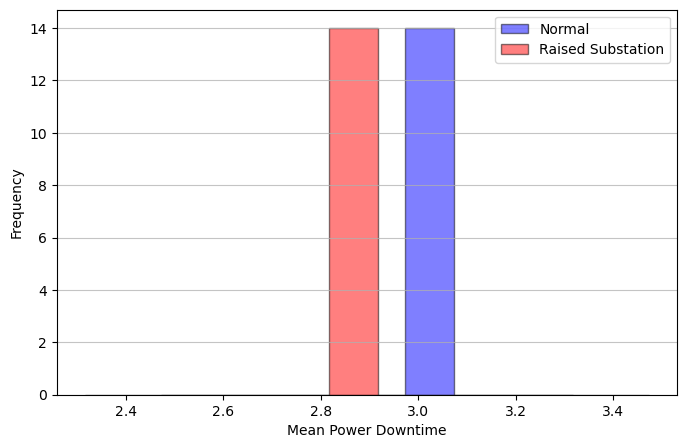

In [9]:
plt.figure(figsize=(8, 5))

plt.hist(buildings_unmitigated['mean_downtime_power'], bins = 10, color = 'blue', edgecolor = 'black', alpha = 0.5, label = 'Normal')
plt.hist(buildings_mitigated['mean_downtime_power'], bins = 10, color = 'red', edgecolor = 'black', alpha = 0.5, label = 'Raised Substation')
# Customize the plotplt.set_title('Building Downtime Comparison')
plt.xlabel('Mean Power Downtime')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

plt.legend()
# Show plot
plt.show()

In [10]:
buildings_unmitigated.mean_downtime_power.mean()

2.9732152004249928

In [11]:
buildings_mitigated.mean_downtime_power.mean()

2.8170606843366905

## Compare Road Downtimes

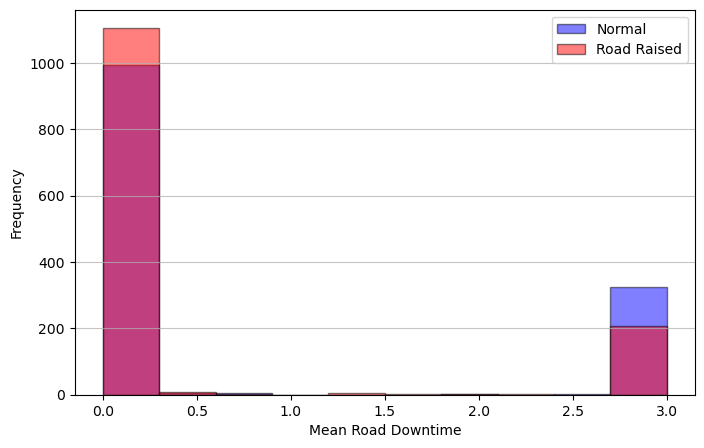

In [13]:
plt.figure(figsize=(8, 5))

plt.hist(edges_unmitigated['mean_downtime'], bins = 10, color = 'blue', edgecolor = 'black', alpha = 0.5, label = 'Normal')
plt.hist(edges_mitigated['mean_downtime'], bins = 10, color = 'red', edgecolor = 'black', alpha = 0.5, label = 'Road Raised')
# Customize the plotplt.set_title('Building Downtime Comparison')
plt.xlabel('Mean Road Downtime')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

plt.legend()
# Show plot
plt.show()

In [14]:
edges_mitigated.mean_downtime.mean()

0.48488151057565737

In [15]:
edges_unmitigated.mean_downtime.mean()

0.7433606908003005

## Compare Individual Recovery Curves

In [17]:
def parse_space_list(s):
    # Remove brackets and split by space
    s = s.strip('[]')            # remove square brackets
    return [float(x) for x in s.split() if x.strip() != '']

In [18]:
# Assume the column with the list is named 'values'
buildings_unmitigated['time'] = buildings_unmitigated['time'].apply(parse_space_list)
buildings_mitigated['time'] = buildings_mitigated['time'].apply(parse_space_list)
buildings_unmitigated['recov'] = buildings_unmitigated['recov'].apply(parse_space_list)
buildings_mitigated['recov'] = buildings_mitigated['recov'].apply(parse_space_list)

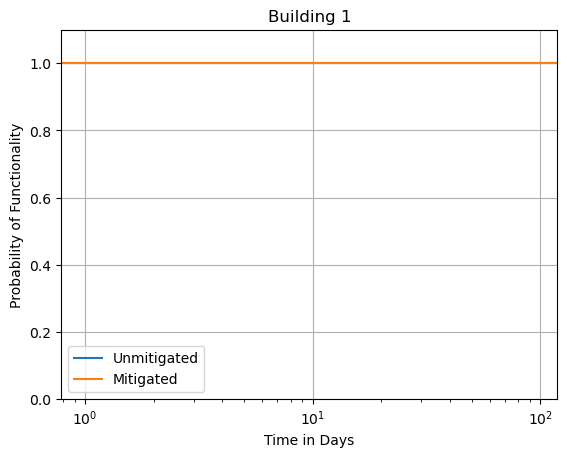

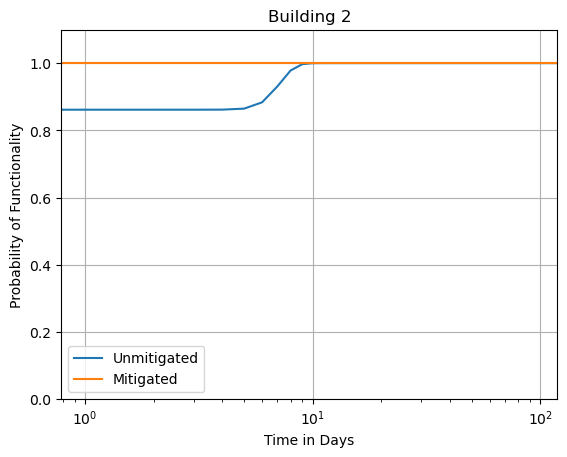

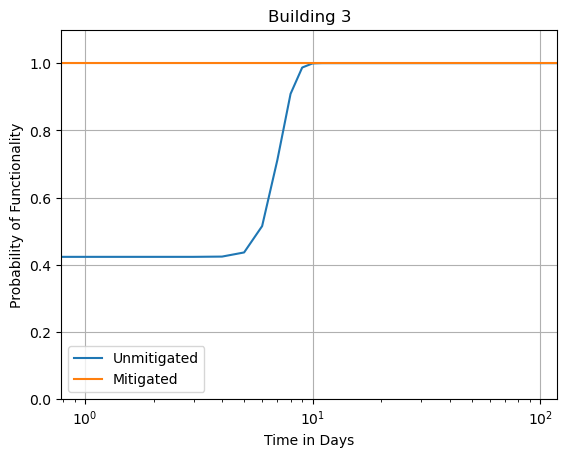

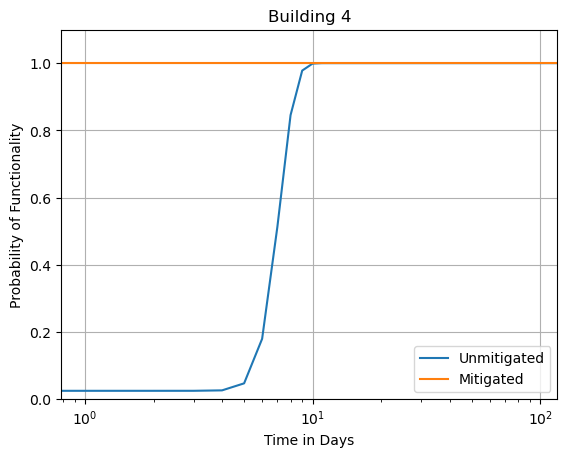

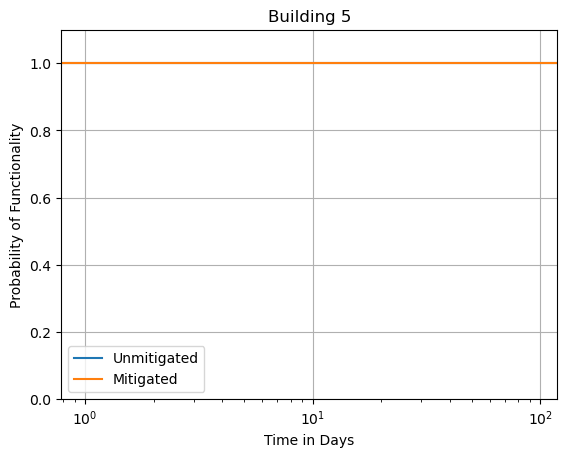

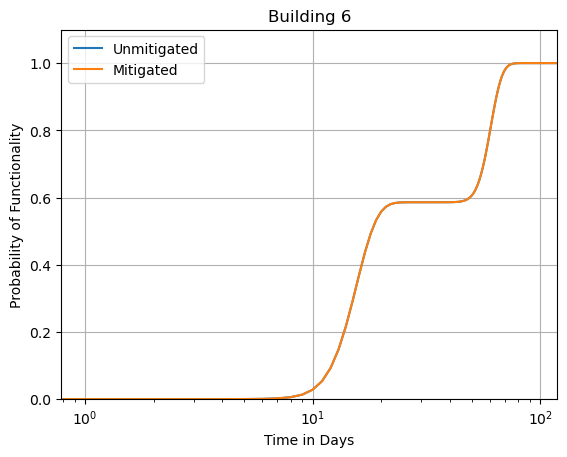

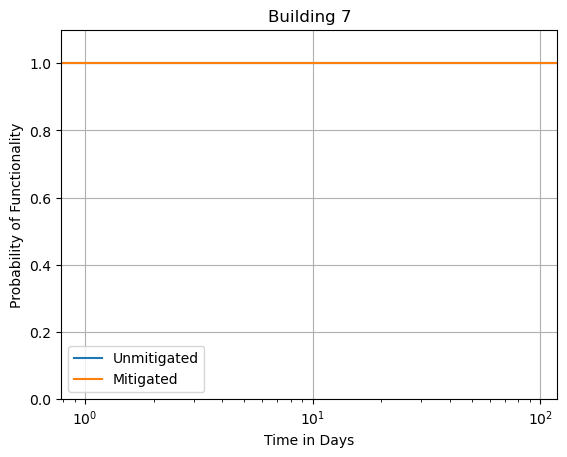

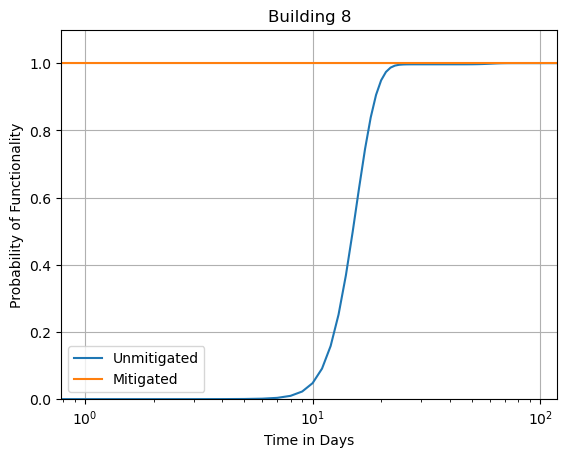

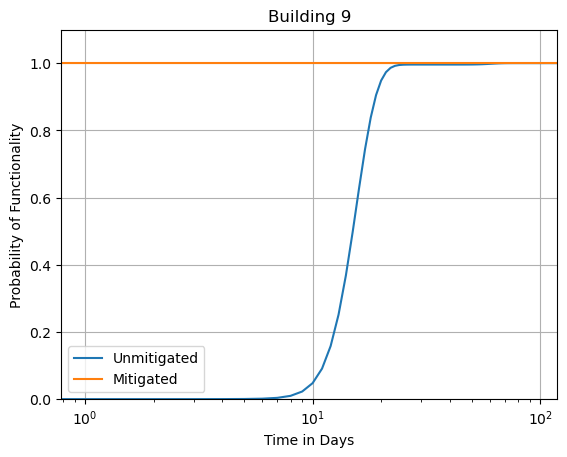

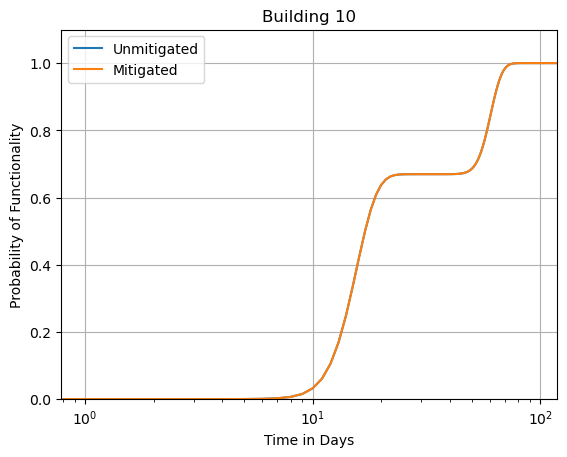

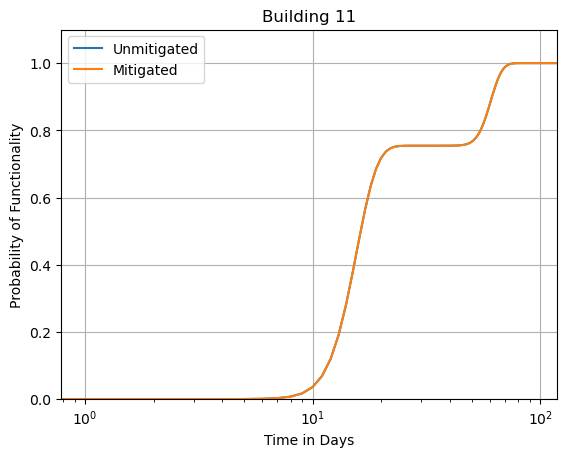

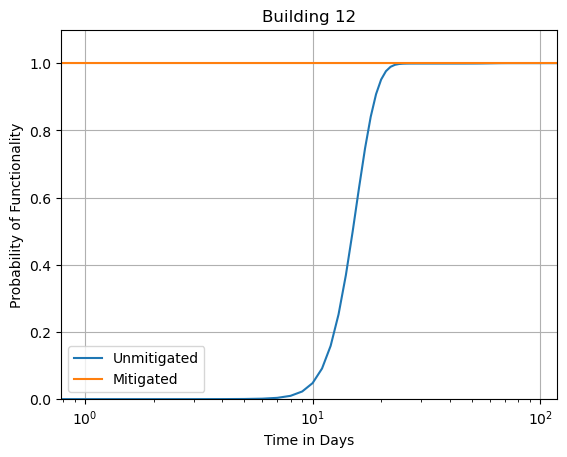

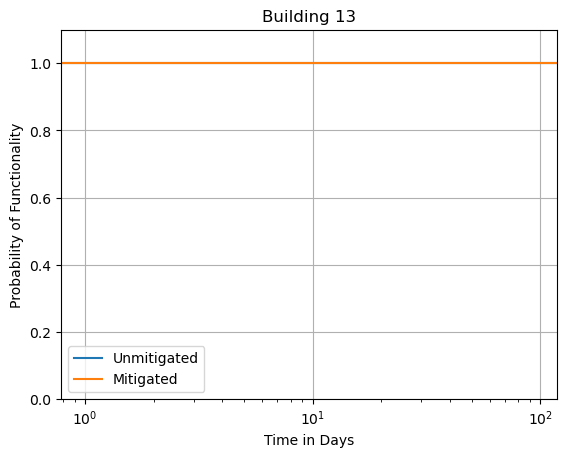

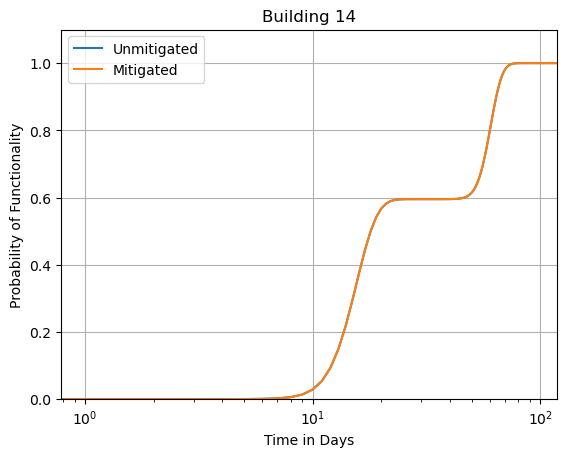

In [19]:
for building_id in range(buildings_mitigated.shape[0]):

    time = buildings_unmitigated.loc[building_id, 'time']
    functionality1 = buildings_unmitigated.loc[building_id, 'recov']
    functionality2 = buildings_mitigated.loc[building_id, 'recov']
    
    plt.xscale('log')
    plt.plot(time, functionality1, label = 'Unmitigated')
    plt.plot(time, functionality2, label = 'Mitigated')
    plt.grid(True)
    plt.ylim(0,1.1)
    plt.xlim(0,np.max(time))
    plt.title('Building {}'.format(building_id+1))
    plt.xlabel('Time in Days')
    plt.ylabel('Probability of Functionality')
    plt.legend()
    
    plt.show()